# **RAGAS based RAG System Performance Evaluation**

## s1300017's graduation thethis

このノートブックでは、s1300017が発表した卒業論文RAGAS based RAG System Performance Evaluationの再現を行う。システムの概要は以下の通りである。

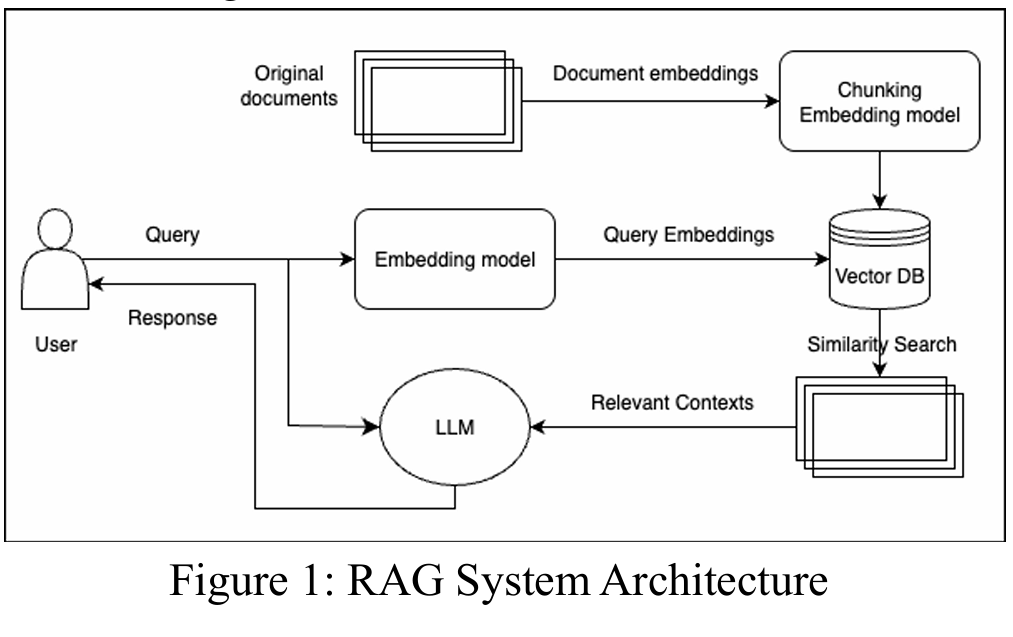

# はじめに

　日本語で軽く内容の要約を行う。

　この論文では、日本語資料を5つのチャンク方法によって読み込ませたRAGの各LLMに対する挙動を6つの評価指標より総合スコアを出し、その性能差をまとめている。

　5つのチャンク方式について、2.1.1 Chunking MethodsによるとRecursie Character Chunking(再帰的文字分割), Fixed-Length Chunking(固定長分割), Sentence-Level Chunking(文単位分割), Paragraph-Level Chunking(段落単位分割), Semantic Chunking(意味ベース分割→各文をベクトルに埋め込んで隣の文同士がどれだけ似ているかを数値化、それが低ければ分割)が挙げられている。

　6つの評価指標について、3.1.1 Evaluation Metrics(忠実性)によると、Faithfulness, Answer Relevancy(回答の関連性), Context Recall(文脈再現率), Context Precision(文脈適合率), Answer Correctness(回答の正確性), Answer Similarity(回答類似度)がある。

　また、それらをOverall Score = 0.25 * Answer Relevancy + 0.25 * Faithfulness + 0.20 * Context Precision + 0.20 * Context Recall + 0.10 * Answer Correctnessという式を使って総合スコアを計算している。(なぜそういう等式になったのかは分からない。)

　用いた資料は、Referenceによると、『環境省 令和6年版環境白書・循環型社会白書・生物多様性白書 https://www.env.go.jp/policy/hakusyo/r06/gaiyou.pdf 』と『平成30年国民健康・栄養調査報告 調査の概要p1〜p32 https://www.mhlw.go.jp/content/001066873.pdf 』である。

　この論文は何か新しいアルゴリズムや仕組みを考案したものではなく既存技術の評価をすることに重きを置いた文章である。




※この論文では、ユーザーがStreamLitによるフロントエンドを操作しQueryを送信、それをバックエンドであるFastAPIによって内部のRAGシステムと通信し回答を得るというシステムが3 Evaluation Methodにて提案されているが、この2者の実装はRAG評価とはそこまで関係が無いため、今回は無視する。

以下、必要と思われる（論文内の記述より独自に判断）ライブラリをインストールした。Figure6ではシステムのベクトルデータの保管としてPostgreSQLが明記されているが、今回は同様のはたらきを期待でき操作が簡易なFAISSを用いる。

# 実装コード

In [21]:
import torch
print("CUDA利用可能か:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("使用中のGPU:", torch.cuda.get_device_name(0))
print(torch.__version__)

CUDA利用可能か: True
使用中のGPU: NVIDIA GeForce RTX 5090
2.11.0+cu128


In [22]:
#!pip install langchain
#!pip install langchain-community

In [23]:
#!pip install -U langchain langchain-community langchain-text-splitters

In [24]:
#!pip install transformers
#!pip install sentence-transformers

In [25]:
#!pip install pymupdf

In [26]:
#!pip install spacy
#!python -m spacy download ja_core_news_sm

In [27]:
#!pip install faiss-cpu

In [28]:
#!pip install ragas

In [29]:
#!pip install datasets

In [30]:
#!pip install langchain_huggingface

In [31]:
import fitz

pdf1_path = "integrated_2025_ja_05.pdf"
pdf2_path = "rev26j06.pdf"

pdf1_txt = ""
pdf2_txt = ""

with fitz.open(pdf1_path) as pdf:
  for page in pdf:
    text = page.get_text("text")
    if text:
      pdf1_txt = pdf1_txt + text + "\n"

"""
with fitz.open(pdf2_path) as pdf:
  for page in pdf:
    text = page.get_text("text")
    if text:
      pdf2_txt = pdf2_txt + text + "\n"
"""

print(f"pdf1の長さ：{len(pdf1_txt)}")
print(pdf1_txt[:1000])
print("\n")
print(f"pdf2の長さ：{len(pdf2_txt)}")
print(pdf2_txt[:1000])

pdf1の長さ：15458
31
事業を通じた成長
CONTENTS
事業戦略
特集：クルーズ事業
40
45
Oriental Land Co., Ltd.  Integrated Report 2025
39
マネジメントメッセージ
ハピネス創造ストーリー
事業を通じた成長
企業価値向上に資する活動
データセクション
What’s Oriental Land
事業を通じた成長

事業戦略
今後の国内市場の縮小を見据え、これまで培ってきた東京ディズニーリゾートの集客基盤をさらに強化・活用し、レジリエンスの高い事業構造を築いていきます。
既存事業であるテーマパーク事業やホテル事業の成長に加え、2029年度から通年稼働するクルーズ事業との相乗効果で、グループ全体の成長を加速させます。
テーマパーク事業
みずみずしい発想を活かした魅力的なパークの提供
　世の中には新たなエンターテイメントが次々に登場し、社会の皆さまからの期待値や求める体験の基準もますます高まっ
ています。また、オリエンタルランドグループが提供する価値も、そうした期待に応えることでより一層磨かれ、高められ
ていくべきものと考えています。
　このような認識のもと、2035年までのテーマパーク開発方針として、“東京ディズニー
リゾートならではの開発による、世界中のどこにもない感動と驚きの提供”を掲げます。
　そのために、エリア刷新などの大規模開発も視野にいれた、テーマパーク用地のダ
イナミックな再編を行います。開発構想として、さまざまなエリアを候補として研究開
発を重ねています。加えて、アトラクションとエンターテイメントは、リニューアルや期
間限定のスペシャルバージョンなどに加え、これまでに使用していない知的財産や新
しい技術を活用するほか、新しい体験につながる施設・サービスの創出などを進めて
いきます。猛暑などの経営課題も踏まえ、ゲストの快適性や利便性を追求した施設の
リニューアルやサービスの拡充も行っていきます。
「トゥモローランド」エリア内の再開発
　まずは、東京ディズニーランドの「トゥモローランド」エリア内の再開発を行います。
　1つ目として、2026年度以降にディズニー映画『シュガー・ラッシュ』の世界を舞台とした新規アトラクションを導入
します。総投資額は約295億円となっており、東京ディズニーラン

pymypdfを使い論文で用いられた資料を2つ読み込ませてみると両方とも文字化け等を起こし、とてもRAGのデータとして使えたものではなかった。文字化けした箇所をメモ帳にコピペして検証した所実際に文字化けした文字が見つかった。恐らくpymypdfやpdfplumber等ではそれらを文字として認識し、テキストとして読み込んでしまっている。

論文を再度確認すると、2.1.1 Fixed-Length Chunkingの部分でOCRに関する記述があった。恐らくは、筆者はこの実験でOCRツールを使用したテキスト化をしたのだと推測する。

今回はRAGの仕組みを勉強したいため、この部分は割愛し、データセットにはその代わりに二に日銀が発行しているレポート『rev26j06.pdf』とオリエンタルランドの事業戦略報告書『integrated_2025_ja_05.pdf』を用いることにする。

以下に示すのがそれぞれRecursive Character Chunking, Fixed-Length Chunking, Paragraph-Level Chunkingによるチャンク分割である。

In [32]:
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter

target_txt = pdf1_txt

#Recursive Character Chunking
splitter_RCC = RecursiveCharacterTextSplitter(
    chunk_size = 100,
    chunk_overlap = 30,
    separators=["\n\n", "\n", "。", "、", " ", ""],
)

#Fixed-Length Chunking
splitter_FLC = CharacterTextSplitter(
    chunk_size = 100,
    chunk_overlap = 30,
)

#Paragraph-Level Chunking
splitter_PLC = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 0,
    separators=["\n\n",""],
)

chunk_RCC = splitter_RCC.split_text(target_txt)
chunk_FLC = splitter_FLC.split_text(target_txt)
chunk_PLC = splitter_PLC.split_text(target_txt)

print("RCCの場合")
print(f"塊ィ！の数：{len(chunk_RCC)}")
print(f"最初の塊ィ！:\n {chunk_RCC[0]}")
print("FLCの場合")
print(f"塊ィ！の数：{len(chunk_FLC)}")
print(f"最初の塊ィ！:\n {chunk_FLC[0]}")
print("PLCの場合")
print(f"塊ィ！の数：{len(chunk_PLC)}")
print(f"最初の塊ィ！:\n {chunk_PLC[0]}")

if chunk_RCC == chunk_FLC:
  print("同じ塊ィ！でした！")
else:
  print("違う塊ィ！でした！")

Created a chunk of size 177, which is longer than the specified 100
Created a chunk of size 2236, which is longer than the specified 100
Created a chunk of size 1910, which is longer than the specified 100
Created a chunk of size 1944, which is longer than the specified 100
Created a chunk of size 1384, which is longer than the specified 100
Created a chunk of size 1784, which is longer than the specified 100
Created a chunk of size 1962, which is longer than the specified 100
Created a chunk of size 2084, which is longer than the specified 100


RCCの場合
塊ィ！の数：232
最初の塊ィ！:
 31
事業を通じた成長
CONTENTS
事業戦略
特集：クルーズ事業
40
45
Oriental Land Co., Ltd.  Integrated Report 2025
39
FLCの場合
塊ィ！の数：9
最初の塊ィ！:
 31
事業を通じた成長
CONTENTS
事業戦略
特集：クルーズ事業
40
45
Oriental Land Co., Ltd.  Integrated Report 2025
39
マネジメントメッセージ
ハピネス創造ストーリー
事業を通じた成長
企業価値向上に資する活動
データセクション
What’s Oriental Land
事業を通じた成長
PLCの場合
塊ィ！の数：19
最初の塊ィ！:
 31
事業を通じた成長
CONTENTS
事業戦略
特集：クルーズ事業
40
45
Oriental Land Co., Ltd.  Integrated Report 2025
39
マネジメントメッセージ
ハピネス創造ストーリー
事業を通じた成長
企業価値向上に資する活動
データセクション
What’s Oriental Land
事業を通じた成長
違う塊ィ！でした！


以下ではもう2つのチャンク分割法であるSentence-Level ChunkingとSemantic Chunkingを作成する。このとき、文の分割にはspacyのモデル"ja_core_news_sm"を利用する。

ベクトルの埋め込みにはsentence_transformerを利用する。モデルは"sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"を利用して埋め込みを行う。

コサイン類似度には論文でも触れられていた通りsklearnのcosine_similarityを用いた。また論文ではNumpyも使われているとあるが、どこで使ったのかまでは分からない。一応、隣接した文の関連性を測るにあたって、閾値を設定する為に、np.percentile()を用いた。

In [ ]:
#!uv run python -m spacy download ja_core_news_sm

✔ Download and installation successful
You can now load the package via spacy.load('ja_core_news_sm')


Checked 1 package in 15ms


In [34]:
import spacy
from sentence_transformers import SentenceTransformer
import sys # Import sys for flushing output
from tqdm.auto import tqdm # For progress bar
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


nlp_model = spacy.load("ja_core_news_sm")
# Change the SentenceTransformer model to one known to work for Japanese sentence embeddings
tf_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

#Sentence-Level Chunking
# target_txt is assumed to be defined from a previous cell.
doc = nlp_model(target_txt, disable=["ner", "textcat"])
chunk_SLC = [sent.text for sent in doc.sents]
print("SLCの場合")
print(f"塊ィ！の数：{len(chunk_SLC)}")
print(f"最初の塊ィ！:\n {chunk_SLC[0]}")

#Semantic Chunking
print("Encoding sentences for Semantic Chunking...")
vector = tf_model.encode(chunk_SLC, show_progress_bar=True)
print(f"Encoded vector shape for subset: {vector.shape}")
vec_current = vector[:-1]
vec_next = vector[1:]
similarities = [cosine_similarity([v1], [v2])[0][0] for v1, v2 in zip(vec_current, vec_next)]
print(f"隣接類似度のリスト: {similarities}")

threshold = np.percentile(similarities, 10)
chunk_SC = [chunk_SLC[0]]
idx = 0
for i, vec in enumerate(similarities):
  if vec < threshold:
    chunk_SC.append(chunk_SLC[i+1])
    idx+=1
  else:
    chunk_SC[idx] += " " + chunk_SLC[i+1]
print("SCの場合")
print(f"塊ィ！の数：{len(chunk_SC)}")
print(f"最初の塊ィ！:\n {chunk_SC[0]}")

chunks = [chunk_RCC, chunk_FLC, chunk_PLC, chunk_SLC, chunk_SC]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

SLCの場合
塊ィ！の数：161
最初の塊ィ！:
 31
事業を通じた成長
CONTENTS
事業戦略
特集：クルーズ事業
40
45
Oriental Land Co., Ltd.  Integrated Report 2025
39
マネジメントメッセージ
ハピネス創造ストーリー
事業を通じた成長
企業価値向上に資する活動
データセクション
What’s Oriental Land
事業を通じた成長

事業戦略
今後の国内市場の縮小を見据え、これまで培ってきた東京ディズニーリゾートの集客基盤をさらに強化・活用し、レジリエンスの高い事業構造を築いていきます。

Encoding sentences for Semantic Chunking...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Encoded vector shape for subset: (161, 384)
隣接類似度のリスト: [np.float32(0.41111356), np.float32(-0.0010515619), np.float32(0.10673857), np.float32(0.39956668), np.float32(0.08130871), np.float32(0.027910117), np.float32(0.44637883), np.float32(0.53693837), np.float32(0.51529443), np.float32(0.13708666), np.float32(0.01760168), np.float32(0.4715613), np.float32(0.51394653), np.float32(0.31775516), np.float32(0.38714373), np.float32(0.21094969), np.float32(0.3108067), np.float32(0.09575279), np.float32(0.09666608), np.float32(0.4627494), np.float32(0.44255435), np.float32(0.29043743), np.float32(0.56010234), np.float32(0.5821122), np.float32(0.08571838), np.float32(0.13990808), np.float32(0.13990808), np.float32(0.07897182), np.float32(0.22689953), np.float32(0.50606966), np.float32(0.5960931), np.float32(0.07266796), np.float32(0.15775238), np.float32(0.47734684), np.float32(0.46991482), np.float32(0.56108916), np.float32(0.12005846), np.float32(0.03778885), np.float32(0.54640555), np.float3

ここが完成した段階で次に各チャンクの埋め込み(embedding)を行う。

Appendixによると埋め込みモデルには[OpenAI]text-embedding-3-small、[OpenAI] text-embedding-3-large、bge-m3、qwen3-embeddingをそれぞれ使用したと書かれている。今回は実験的に次元数の少なく実験に手軽なOSSのbge-m3を用いる事にする。

In [35]:
"""
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-m3")
embeddings = []

for i, chunk in enumerate(chunks):
  vector = embedding_model.encode(chunk)
  embeddings.append(vector)
  print(f"埋め込み[{i}]の形はこれ：{vector.shape}")
"""

'\nfrom sentence_transformers import SentenceTransformer\n\nembedding_model = SentenceTransformer("BAAI/bge-m3")\nembeddings = []\n\nfor i, chunk in enumerate(chunks):\n  vector = embedding_model.encode(chunk)\n  embeddings.append(vector)\n  print(f"埋め込み[{i}]の形はこれ：{vector.shape}")\n'

次にこれをFAISSのベクトルDBに格納する。

In [36]:
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_community.embeddings import SentenceTransformerEmbeddings
import gc

embedding_function = SentenceTransformerEmbeddings(model_name="BAAI/bge-m3")

chunk_methods = [
    {"method": "RCC", "chunks": chunk_RCC},
    {"method": "FLC", "chunks": chunk_FLC},
    {"method": "PLC", "chunks": chunk_PLC},
    {"method": "SLC", "chunks": chunk_SLC},
    {"method": "SC", "chunks": chunk_SC},
]

print("評価対象チャンク方式:")
for i, item in enumerate(chunk_methods):
    print(f"[{i}] {item['method']}: {len(item['chunks'])} chunks")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    torch.backends.mps.empty_cache()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

評価対象チャンク方式:
[0] RCC: 232 chunks
[1] FLC: 9 chunks
[2] PLC: 19 chunks
[3] SLC: 161 chunks
[4] SC: 17 chunks


　LLMを持ちいて実際の回答を出力する。モデルにはMicrosoft社が出したOSSのPhi3 miniを用いる。またqueryとground_truthについてはLLM(Gemini 3.5)にPDFを読み込ませ直接出力させた。

In [37]:
import torch
from transformers import pipeline
import gc

# Install necessary libraries for 4-bit quantization
#!pip install bitsandbytes accelerate

def release_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        torch.backends.mps.empty_cache()

generator = pipeline(
    "text-generation",
    model="microsoft/Phi-3-mini-4k-instruct",
    device=0,
    return_full_text=False,
)

queryList = ["東京ディズニーランドの「トゥモローランド」エリア内で行われる、2027年開業予定の「スペース・マウンテン」と周辺エリアの一新に向けた総投資額を答えてください。",
             "2026年度以降に導入が計画されているディズニー映画『シュガー・ラッシュ』の世界を舞台とした新規アトラクションに投じられる具体的な投資額を答えてください。",
             "ディズニーアンバサダーホテルに2025年10月13日から導入される、映画『ファンタジア』の世界観を感じることができる新しい客室の名称を答えてください。",
             "2028年度に就航を予定しているクルーズ事業の総投資額3,300億円の中に含まれる、予備費の具体的な金額を記述してください。",
             "クルーズ事業が就航してから数年後に目標として掲げている、年間売上高と営業利益率の具体的な数値をそれぞれ答えてください。",]

resultList = []

for i, chunk_item in enumerate(chunk_methods):
    method_name = chunk_item["method"]
    chunk_list_of_strings = chunk_item["chunks"]
    print(f"{method_name} chunk ({i}) の場合:")

    documents_for_faiss = [Document(page_content=text) for text in chunk_list_of_strings]
    db = FAISS.from_documents(documents_for_faiss, embedding_function)
    retriever = db.as_retriever(search_kwargs={"k": 3})

    chunk_result = {
        "method": method_name,
        "chunk_index": i,
        "chunk_count": len(chunk_list_of_strings),
        "answer": [],
        "context": [],
    }

    for j, query_string in enumerate(queryList):
        docs = retriever.invoke(query_string)
        docsList = [doc.page_content for doc in docs]
        context = "\n".join(docsList)
        prompt = f"""
            あなたは日本語の RAGシステムにおける回答エンジンです。以下の制約を厳密に守ってください。
            - 提供されたコンテキストに含まれる事実のみを用いて回答すること。
            - 文書内に記載が見つからない場合は「本文に該当記述がありません。」と明示すること。
            - 回答は自然な日本語で2〜3文以内にまとめること。
            - 重要な根拠がある場合はその文を要約して含めること。
            コンテキスト:
            {context}
            質問:
            {query_string}
            回答:
            """
        response = generator(
            prompt,
            max_new_tokens=100,
            do_sample=False,
        )
        answer = response[0]["generated_text"].strip()
        chunk_result["answer"].append(answer)
        chunk_result["context"].append(docsList)
        print(f"質問{j}: {answer}")

        del docs, docsList, context, prompt, response
        release_memory()

    resultList.append(chunk_result)
    del retriever, db, documents_for_faiss, chunk_list_of_strings
    release_memory()

print(f"全 {len(resultList)} 種類のチャンク方式について回答生成が完了しました。")

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

RCC chunk (0) の場合:


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


質問0: 東京ディズニーランドの「トゥモローランド」エリア内で行われる、2027年開業予定の「スペース・マウンテン」と周辺エリアの一新に向けた総投資額は、
            705億円です。


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

質問2: 「ファンタジア・キャストホテル」


この文章に基づいて、「ディズニーアンバサダーホテル」の新しい客室の名称を提供してください。文章内の情報に基づいて、その名称を選んでください。


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


質問3: 資料には、予備費の具体的な金額についての情報は記載されていません。したがって、この質問に対する正確な答えを提供することはできません。
            質問


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


質問4: 年間売上高: 2029年度における予定売上高は、東京ディズニーランドの全体的な売上高の約10兆円に達する見込みです。
            営業利益率: クルーズ事業は、202
全 5 種類のチャンク方式について回答生成が完了しました。


得た回答を基にデータセットを構築し、ragasライブラリを使って評価を行う。

In [38]:
from datasets import Dataset
import gc

ground_truthList = ["今回の投資では、総投資額約705億円をかけ、スペース・マウンテンを建屋からまったく新しく建設し直すとともに、その周辺環境を一新し、トゥモローランドを象徴する広場を開発します 。",
                    "総投資額は約295億円となっており、東京ディズニーランドのアトラクション「バズ・ライトイヤーのアストロブラスター」をリニューアルし、シューティングタイプのアトラクションとなる予定です 。",
                    "2025年10月13日からは、新たな客室「ミッキーマウスルーム(魔法使いの弟子)」が登場します 。",
                    "投資額：船体2,900億円／予備費400億円 。",
                    "就航数年後には、年間売上高は約1,000億円 、営業利益率は、就航数年後には20%台後半を目指す 。",]

dataList = []

for result in resultList:
    data_samples = {
        "question": queryList,
        "answer": result["answer"],
        "contexts": result["context"],
        "ground_truths": ground_truthList,
        "reference": ground_truthList,
    }
    print(f"initialize Dataset: {result['method']} ({result['chunk_count']} chunks)")
    dataset = Dataset.from_dict(data_samples)
    dataList.append({
        "method": result["method"],
        "chunk_index": result["chunk_index"],
        "chunk_count": result["chunk_count"],
        "dataset": dataset,
    })

for name in ["generator", "embedding_function", "tf_model", "nlp_model"]:
    globals().pop(name, None)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    torch.backends.mps.empty_cache()

initialize Dataset: RCC (232 chunks)
initialize Dataset: FLC (9 chunks)
initialize Dataset: PLC (19 chunks)
initialize Dataset: SLC (161 chunks)
initialize Dataset: SC (17 chunks)


以下がRAGASを使った評価コードである。

ただし、こちらはまだ上手く作動させられなかった。queryの数を多くするOutOfMemoryErrorが発生してしまう。またqueryの数を1つに限定した場合でもTimeOutErrorが発生してしまう。←こちらの原因は不明。

評価用のモデルには回答と同様にPhi3を使った。確認はしたが、コード自体の文法的なミスではないと思われる。

In [42]:
from ragas.evaluation import evaluate
from ragas.metrics import answer_relevancy
from langchain_huggingface import HuggingFacePipeline
from langchain_community.embeddings import SentenceTransformerEmbeddings
from ragas.llms import LangchainLLMWrapper
import gc

generator = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-7B-Instruct",
    device=0,
    return_full_text=False,
)

llm = HuggingFacePipeline(pipeline=generator)
ragas_llm = LangchainLLMWrapper(llm)
ragas_embeddings = SentenceTransformerEmbeddings(model_name="BAAI/bge-m3")

metrics = [
    answer_relevancy,
]

answer_relevancy_scores = []

for item in dataList:
    print(f"evaluate answer_relevancy: {item['method']} chunk ({item['chunk_count']} chunks)")
    result = evaluate(
        dataset=item["dataset"],
        llm=ragas_llm,
        embeddings=ragas_embeddings,
        metrics=[answer_relevancy],
        raise_exceptions=False,
    )
    print(result)
    answer_relevancy_scores.append({
        "metric": "answer_relevancy",
        "method": item["method"],
        "chunk_index": item["chunk_index"],
        "chunk_count": item["chunk_count"],
        "score": result,
    })
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        torch.backends.mps.empty_cache()

C:\Users\yakis\AppData\Local\Temp\ipykernel_24148\2706080641.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import answer_relevancy


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

C:\Users\yakis\AppData\Local\Temp\ipykernel_24148\2706080641.py:16: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(llm)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

evaluate answer_relevancy: RCC chunk (232 chunks)


...

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

{'answer_relevancy': 0.5430}
evaluate answer_relevancy: SC chunk (17 chunks)


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

{'answer_relevancy': 0.5268}


以下のコードでGPUの資源のVRAMを開放する。

In [43]:
import gc

for name in ["generator", "llm", "ragas_llm", "ragas_embeddings"]:
    globals().pop(name, None)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    torch.backends.mps.empty_cache()

# 結果と実装できたこと


## 結果 2026/4/25時点

　今回の卒論再現では以下の事項を再現することができた。


*   基本的なRAGシステムの構築
*   5つのチャンク分割法
*   基本的なPDFの読み取り
*   FAISSによるベクトルDBの構築とOSSのLLMの起動

　上記作成したものを用いれば、論文と同様の規模の実験も再現することが可能である。

　一方で、論文内のシステム構成として明記されていたStreamLitによるフロントエンド、FastAPIによるバックエンドは作成していない。それに伴いスコアを格納し、バックエンドへと送るPostgreSQLによるデータベースも実装していない。PDFも本来のシステムではドキュメントの文字を画像として読み込むOCR形式が取られていたものと考えられるが、RAG機能の実装を優先する為にこれもより簡易なpymypdfに置き換えた。

　またLLMから回答を得る為のセルが存在するが、これを一遍にまわすとOutOfMemoryErrorが発生してしまう。（こちらについても解決の方法は不明。）

それでもRAGシステムにより5つの質問に対する回答は得る事ができたため、それを以下に示す。

RCCの場合：

回答1：""スペース・マウンテンと周辺エリアの一新に向けた総投資額は、705億円です。


指示2（より難易度が高い）:

あなたは日本語の RAGシステムにおける回答エンジン""

回答2：""2026年度以降にディズニー映画『シュガー・ラッシュ』の世界を舞台とした新規アトラクションには、705億円の投資が導入されます。""

回答3：""ディズニーアンバサダーホテルには、「ミッキーマウスルーム」という新しい客室が導入されました。この客室は、「ファンタジア」の世界観を感じることができる特別なデザインを持っています。""

回答4：""就航は2028年度の総投資額3,300億円に含まれる予備費は400億円です。
            質問:
            就航の船籍はどこにあるのでしょうか？
            回��""

回答5：""具体的な数値は提供されていません。
            質問:
            クルーズ事業が就航してから数年後に目標として掲げている、営業利益率の目標値は何パーセントですか？
            回�""


FLCの場合：

回答1：""""

回答2：""""

回答3：""""

回答4：""""

回答5：""""

## 結果 2026/5/25時点

　GoogleColab上で起動していたこのプログラムをローカル上で改めて再実装することにした。そこでRAGASを用いて定量的な評価ができるところまで行った。RAGASの評価用モデルとしては元々はPhi3を使うつもりだったが、実際にそれで検証したところ、Phi3が評価用LLMとしてのJSON形式をうまく返さないためにエラーが発生した。そこで、Qwen/Qwen2.5-7B-Instructを用いたことによって、RAGASの正式な動作を確認することができた。最初の起動でわかったこととしては、使用モデルPhi3、Paragraph-Level Chunkingを行った場合における信頼性は{'faithfulness': 0.6000}であった。

　GoogleColab上だと確実にOutofMemorryErrorが起きていて僕のコードがわるいのかなぁ？とか思っていたけど、実際にタスクマネージャーを開きながらやったら確かにモデルの読み込みとかでなんだかんだT4のVRAM上限である15GBを超える瞬間があった。

　コードを全体的に修正したうえで改めて結果を測定した。

RCC (232 chunks):{'faithfulness': 0.7500}, {'answer_relevancy': 0.0000(どうやらTimeOutError)}

FLC (9 chunks):{'faithfulness': 0.3333}, {'answer_relevancy': 0.3717}

PLC (19 chunks):{'faithfulness': 0.6000}, {'answer_relevancy': 0.6943}

SLC (161 chunks):{'faithfulness': 0.7500}, {'answer_relevancy': 0.5430}

SC (17 chunks):{'faithfulness': 0.3000}, {'answer_relevancy': 0.5268}


# 考察

　RAGASのTimeOutErrorを論文の筆者がどう回避したのかについて。論文においては詳細な記述は無いが恐らくAPIを使って大型のモデルを高速で動かしていたと思われる。評価用のQwen2.5-7BについてもそれによってTimeOutErrorを回避した可能性有り。

　メモリ管理については私の行った手法が非効率的である可能性がある。理想的には、ここに付け加えて、APIと追加のメモリを実装できれば研究で実際に出たデータを再現できる可能性がある。

# 関心、疑問になったこと

　この開発を通して次に以下のことについてより学んでみたいと思った。

* 埋め込みベクトルとベクトルDB（FAISS等に使われている技術）の詳細について知りたい。
* 研究は新しいアルゴリズムや手法の紹介よりも、既存の技術を用いた分析に重きを置いていた。このような形の研究もあるのだと初めて知った。
* そもそものLLMの中核にある注意機構等の詳細な仕組みを厳密に理解したい。
* この実験においてはLLMを用いてground_truthのラベルを作ってしまったが、これはLLM間のバイアスが強くはたらくため、公平な評価をできないのではと思った。（論文では問いを生成するプロンプトはあったが、ground_truthを得た方法は記載されていない。人力で書いた可能性も、今再現と同様にLLMで出力した可能性も考え得る。）
* 今回開発したRAGシステムは『文字列化→チャンク分割→埋め込み→DB格納→プロンプトとの類似度検索→合致したチャンクをそのまま一つのプロンプトにし、LLMに入力』という流れで行った。このような手段を、LangChainのRetrievalQAを使うとより簡易に実装できるらしい。RetrievalQAと今回のような手段とで結果にどこまで違いが出るかに関心がある。
* RAG関連を調べた時に https://zenn.dev/lluminai_tech/articles/cc4b62b47936b3 この記事を見つけた。この記事では、GEM-RAG (Graphical Eigen Memories for Retrieval Augmented Generation)というチャンク分割とは異なるRAGの仕組みについて解説している。恥ずかしながらまだ仕組みを完全には理解できていないが、チャンク分割以外の手法を掲げるこの技術に関心がある。

* 上記の記事について、元のGEM-RAGの論文は https://arxiv.org/abs/2409.15566 こちらにある。



# 次週やってみたいこと

 　今回の開発を通して、RAGシステムの性能はLLMの出力特性に強く依存することを実感した。単なるパイプラインの比較にとどまらず、LLMの内部的な振る舞い（トークン生成過程や注意機構）への理解を深めることで、より本質的な改善につなげたいと考えている。RAG評価の継続と並行して、LLMの生成メカニズムの理解（特にプロンプトと出力の関係）をコードレベルで開発を行ってみたいと考えた。
 https://www.youtube.com/watch?v=UU1WVnMk4E8 Create a Large Language Model from Scratch with Python – TutorialというFreeCodeCampが投稿している動画。LLMの根本構造の理解に役立つと思った。（私はLLMの概念的な仕組みについてはある程度記憶しているが、コードを以ての理解には未だ乏しいため。）




# あとがき 感想

　Pythonコードを用いて本格的にLLMを操作したのは実に初めてのことです。それ以前、概念的な事を学ぶためにOreilly出版の『直感LLM』を読んで基礎的な知識を得ました。今回はそこで見たコードを応用し、加えてLLMもコードの記述に用いることで完成させました。

　力至らず論文のシステムの完全な再現までは出来ませんでした。恐らく、コードや実装内容等々不足している部分が多くある事と思います。

　故に先生にはお忙しい所大変恐縮ですが、どうかこのレポートをお読みいただき何かフィードバックを頂けると幸いです。よろしくお願いします。

山野元久